# What makes a molecule dissolve in water?

**An analysis of aqueous solubility for 1,128 molecules, and where today's models still fail.**

Water solubility decides whether a drug can be absorbed, how far a pesticide spreads in groundwater, and how a chemical behaves in a spill. It is also expensive to measure, so chemists rely on predictions.

This notebook uses the **ESOL** dataset (Delaney, 2004; distributed by MoleculeNet), which lists measured solubility for 1,128 molecules. It asks five questions:

1. Which molecular properties drive solubility?
2. How well can solubility be predicted from structure alone?
3. For which chemical families do predictions fail?
4. Are molecules that look unlike the rest of the data predicted worse?
5. Would more data help?

It ends with **open research questions** that the errors point to.

> **Units.** Solubility is `logS`, the base-10 log of solubility in mol/L. `logS = -2` means 0.01 mol/L; every step of 1 is a 10× difference.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
IMAGES = ROOT / "images"
IMAGES.mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold, learning_curve

import chem

BG, FG, MUTED, GRID = "#14120f", "#f5f1e6", "#9a958a", "#2e2b25"
ACCENT, WARN = "#d7ff3f", "#ff7a59"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG, "savefig.facecolor": BG,
    "text.color": FG, "axes.labelcolor": FG, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": GRID, "grid.color": GRID, "axes.grid": True, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "font.size": 12, "axes.titlesize": 15, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
})
pd.set_option("display.precision", 2)

def save(fig, name):
    fig.savefig(IMAGES / name)
    plt.show()

## 1. Load and describe the data

Each molecule is stored as a SMILES string, which RDKit turns into a molecular graph. From that graph `chem.analyse()` computes 11 standard descriptors, tags chemical families, and makes out-of-fold model predictions (see section 3).

In [2]:
df, DESCRIPTOR_COLS, FAMILY_COLS = chem.analyse()
print(f"{len(df):,} molecules, logS from {df.logS.min():.1f} to {df.logS.max():.1f} "
      f"(a {10 ** (df.logS.max() - df.logS.min()):.0e}x range)")
df[["name", "smiles", "logS"] + DESCRIPTOR_COLS].head()

1,128 molecules, logS from -11.6 to 1.6 (a 2e+13x range)


,name,smiles,logS,logP,MW,TPSA,HBD,HBA,RotB,AromProp,AromRings,FracSP3,Halogens,HeavyAtoms
0,Amigdalin,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77,-3.11,457.43,202.32,7,12,7,0.19,1,0.65,0,32
1,Fenfuram,Cc1occc1C(=O)Nc2ccccc2,-3.30,2.84,201.23,42.24,1,2,2,0.73,2,0.08,0,15
2,citral,CC(C)=CCCC(C)=CC(=O),-2.06,2.88,152.24,17.07,0,1,4,0.00,0,0.50,0,11
3,Picene,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87,6.30,278.35,0.00,0,0,0,1.00,5,0.00,0,22
4,Thiophene,c1ccsc1,-1.33,1.75,84.14,0.00,0,1,0,1.00,1,0.00,0,5


In [3]:
df[["logS", "logP", "MW", "TPSA", "HBD", "AromRings", "Halogens"]].describe().T[["mean", "50%", "min", "max"]]

,mean,50%,min,max
logS,-3.05,-2.86,-11.60,1.58
logP,2.45,2.34,-7.57,10.39
MW,203.94,182.18,16.04,780.95
TPSA,34.87,26.30,0.00,268.68
HBD,0.70,0.00,0.00,11.00
AromRings,0.93,1.00,0.00,7.00
Halogens,0.74,0.00,0.00,12.00


## 2. What drives solubility?

Correlation of each descriptor with measured `logS`. Negative means *more of this, less soluble*.

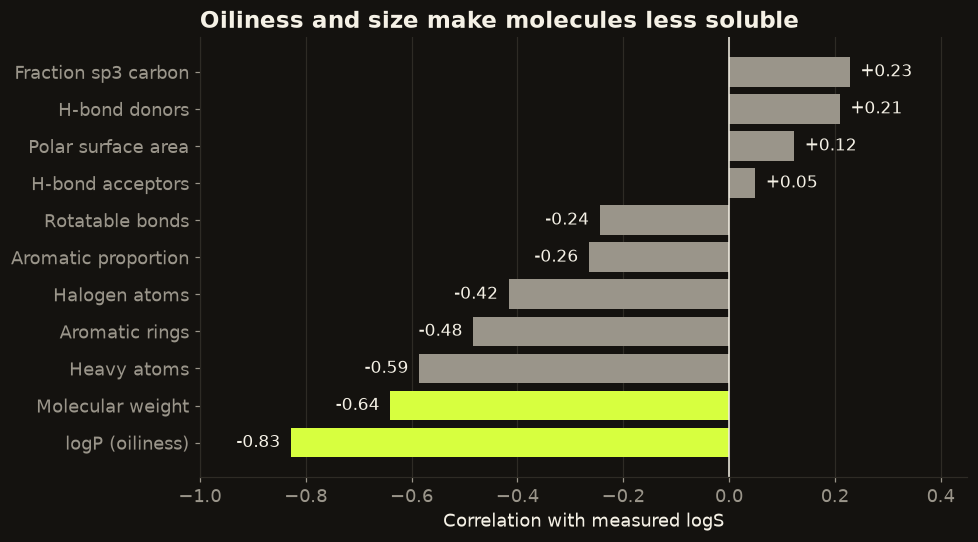

In [4]:
corr = df[DESCRIPTOR_COLS + ["logS"]].corr()["logS"].drop("logS").sort_values()
labels = {"logP": "logP (oiliness)", "MW": "Molecular weight", "HeavyAtoms": "Heavy atoms", "AromRings": "Aromatic rings",
          "Halogens": "Halogen atoms", "AromProp": "Aromatic proportion", "RotB": "Rotatable bonds", "HBA": "H-bond acceptors",
          "TPSA": "Polar surface area", "HBD": "H-bond donors", "FracSP3": "Fraction sp3 carbon"}
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh([labels[c] for c in corr.index], corr.values, color=[ACCENT if abs(v) > 0.6 else MUTED for v in corr.values])
for y, v in enumerate(corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), y, f"{v:+.2f}", va="center", ha="left" if v >= 0 else "right", fontsize=11)
ax.axvline(0, color=FG, lw=1)
ax.set_xlim(-1, 0.45)
ax.set_title("Oiliness and size make molecules less soluble")
ax.set_xlabel("Correlation with measured logS")
ax.grid(axis="y", visible=False)
save(fig, "01_drivers.png")

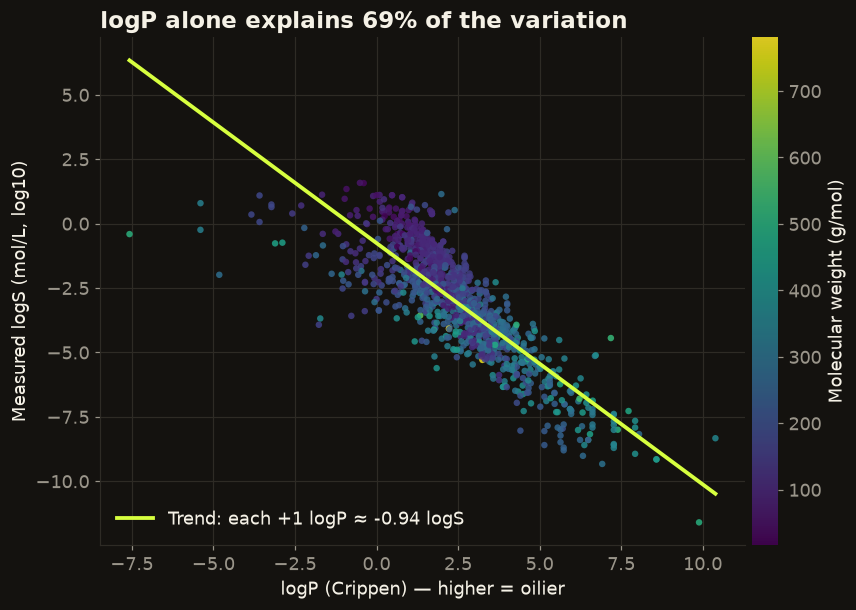

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df.logP, df.logS, c=df.MW, cmap="viridis", s=18, alpha=0.85, linewidths=0)
cb = fig.colorbar(sc, ax=ax, pad=0.01)
cb.set_label("Molecular weight (g/mol)")
cb.outline.set_visible(False)
m, b = np.polyfit(df.logP, df.logS, 1)
xs = np.linspace(df.logP.min(), df.logP.max(), 50)
ax.plot(xs, m * xs + b, color=ACCENT, lw=2.5, label=f"Trend: each +1 logP ≈ {m:.2f} logS")
ax.legend(frameon=False, loc="lower left")
ax.set_xlabel("logP (Crippen) — higher = oilier")
ax.set_ylabel("Measured logS (mol/L, log10)")
ax.set_title(f"logP alone explains {np.corrcoef(df.logP, df.logS)[0, 1] ** 2:.0%} of the variation")
save(fig, "02_logp_vs_solubility.png")

**Takeaway.** Oiliness (logP) dominates: it alone explains about two thirds of the variation. Bigger molecules (weight, heavy atoms), more aromatic rings and more halogens all lower solubility. H-bond donors (–OH, –NH) help, but only weakly.

## 3. How well can we predict solubility?

Three predictors are compared:

- **ESOL equation.** Delaney's published 4-descriptor linear model. Its predictions ship with the dataset and were **fitted on these same molecules**, so its error is optimistic.
- **Random forest (11 descriptors).** Evaluated with **5-fold cross-validation**: every molecule is predicted by a model that never saw it during training.
- **Baseline.** Always predict the average `logS`.

In [6]:
def scores(pred):
    r = df.logS - pred
    return {"RMSE": chem.rmse(r), "MAE": float(np.mean(np.abs(r))), "R²": 1 - np.sum(r ** 2) / np.sum((df.logS - df.logS.mean()) ** 2)}

results = pd.DataFrame({
    "Baseline (mean)": scores(np.full(len(df), df.logS.mean())),
    "ESOL equation (in-sample)": scores(df.esol_pred),
    "Random forest (5-fold CV)": scores(df.pred),
}).T
results

,RMSE,MAE,R²
Baseline (mean),2.10,1.66,0.00
ESOL equation (in-sample),0.91,0.70,0.81
Random forest (5-fold CV),0.70,0.51,0.89


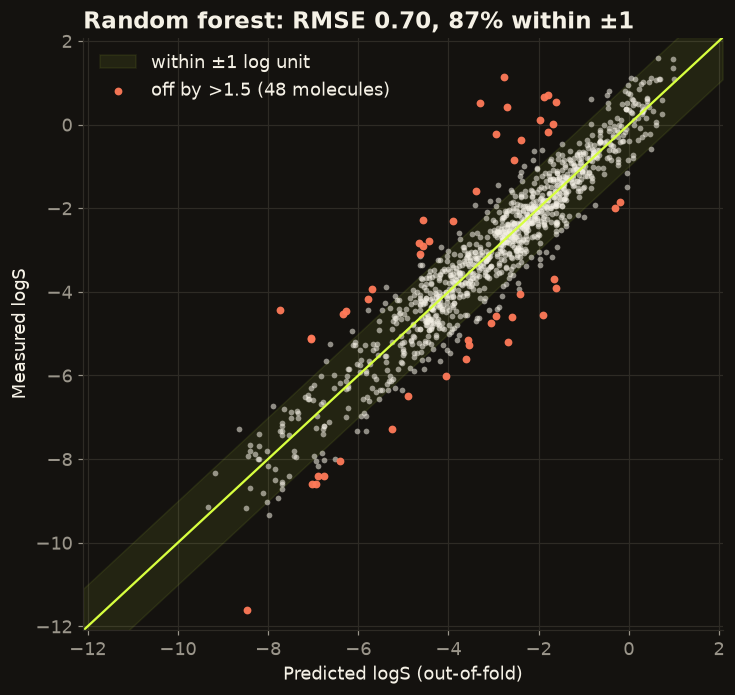

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 7))
lim = (df.logS.min() - 0.5, df.logS.max() + 0.5)
ax.fill_between(lim, [lim[0] - 1, lim[1] - 1], [lim[0] + 1, lim[1] + 1], color=ACCENT, alpha=0.08, label="within ±1 log unit")
ax.plot(lim, lim, color=ACCENT, lw=1.5)
bad = df.residual.abs() > 1.5
ax.scatter(df.pred[~bad], df.logS[~bad], s=14, color=FG, alpha=0.55, linewidths=0)
ax.scatter(df.pred[bad], df.logS[bad], s=26, color=WARN, alpha=0.95, linewidths=0, label=f"off by >1.5 ({bad.sum()} molecules)")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Predicted logS (out-of-fold)")
ax.set_ylabel("Measured logS")
within = (df.residual.abs() <= 1).mean()
ax.set_title(f"Random forest: RMSE {chem.rmse(df.residual):.2f}, {within:.0%} within ±1")
ax.legend(frameon=False, loc="upper left")
save(fig, "03_predicted_vs_measured.png")

**Takeaway.** Out-of-fold, the random forest has lower error than the ESOL equation, even though the equation was fitted on these very molecules. Most predictions land within ±1 log unit, but the orange points are off by more than 30×, and they are not random.

## 4. Where does the model fail?

The error, broken down by chemical family. `mean residual` > 0 means the molecules are **more soluble than predicted**.

In [8]:
rows = []
for fam in FAMILY_COLS:
    r = df.loc[df[fam], "residual"]
    rows.append({"family": fam, "molecules": len(r), "RMSE": chem.rmse(r), "mean residual": r.mean()})
by_family = pd.DataFrame(rows).sort_values("RMSE", ascending=False).reset_index(drop=True)
overall = chem.rmse(df.residual)
by_family

,family,molecules,RMSE,mean residual
0,Organophosphate,43,1.39,0.63
1,Fused aromatic (3+ rings),65,1.01,0.05
2,Heavily halogenated,76,0.90,0.01
3,Ester,98,0.78,-0.08
4,Amine,94,0.74,-0.23
5,Alcohol,154,0.74,0.13
6,Nitro,58,0.63,-0.29


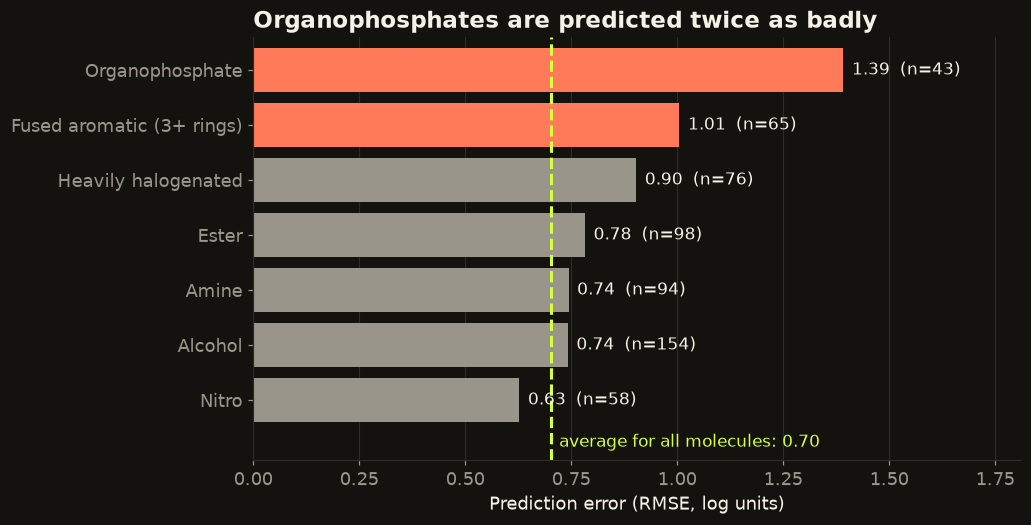

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = [WARN if v > overall * 1.3 else MUTED for v in by_family.RMSE]
ax.barh(by_family.family[::-1], by_family.RMSE[::-1], color=colors[::-1])
ax.axvline(overall, color=ACCENT, lw=2, ls="--")
ax.text(overall + 0.02, -0.85, f"average for all molecules: {overall:.2f}", color=ACCENT, fontsize=11)
ax.set_ylim(-1.1, len(by_family) - 0.4)
for y, (v, n) in enumerate(zip(by_family.RMSE[::-1], by_family.molecules[::-1])):
    ax.text(v + 0.02, y, f"{v:.2f}  (n={n})", va="center", fontsize=11)
ax.set_xlim(0, by_family.RMSE.max() * 1.3)
ax.set_xlabel("Prediction error (RMSE, log units)")
ax.set_title("Organophosphates are predicted twice as badly")
ax.grid(axis="y", visible=False)
save(fig, "04_error_by_family.png")

In [10]:
worst = df.assign(abs_err=df.residual.abs()).nlargest(10, "abs_err")
worst[["name", "logS", "pred", "residual", "smiles"]].rename(columns={"logS": "measured", "pred": "predicted"})

,name,measured,predicted,residual,smiles
1064,vamidothion,1.14,-2.77,3.91,CNC(=O)C(C)SCCSP(=O)(OC)(OC)
292,Dimecron,0.52,-3.31,3.83,CCN(CC)C(=O)C(=CCOP(=O)(OC)OC)Cl
939,bromadiolone,-4.45,-7.73,3.28,OC(CC(c1ccccc1)c3c(O)c2ccccc2oc3=O)c4ccc(cc4)c...
603,"2,2',3,3',4,4',5,5',6,6'-PCB",-11.60,-8.46,-3.14,Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(C...
796,Triethyl phosphate,0.43,-2.71,3.14,CCOP(=O)(OCC)OCC
485,Trichlorfon,-0.22,-2.95,2.73,COP(=O)(OC)C(O)C(Cl)(Cl)Cl
686,simazine,-4.55,-1.90,-2.65,CCNc1nc(Cl)nc(NCC)n1
804,Azodrin,0.65,-1.89,2.54,CNC(=O)C=C(C)OP(=O)(OC)OC
1111,Anthraquinone,-5.19,-2.67,-2.52,O=C1c2ccccc2C(=O)c3ccccc13
683,Antipyrene,0.71,-1.79,2.50,Cc1cc(=O)n(c2ccccc2)n1C


**Takeaway.** Half of the ten worst predictions are **organophosphates** (P=O / P=S esters, common in pesticides). Every one of them is far *more* soluble than predicted. Three of the others (decachlorobiphenyl, simazine, anthraquinone) are rigid, high-melting crystalline solids that are *less* soluble than predicted. Section 7 turns both into research questions.

## 5. Are unfamiliar molecules predicted worse?

For each molecule, the similarity (Tanimoto, Morgan fingerprints) to its **closest other molecule** in the dataset. Low similarity means the model has seen nothing like it.

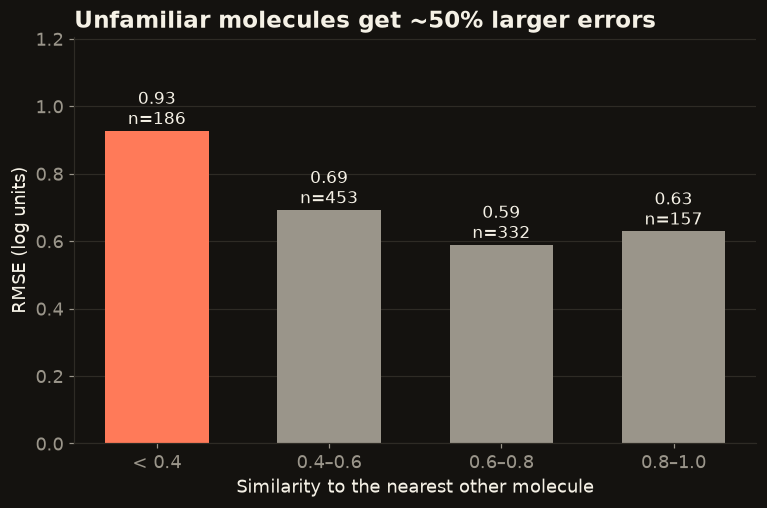

,molecules,RMSE
nn_similarity,,
< 0.4,186,0.93
0.4–0.6,453,0.69
0.6–0.8,332,0.59
0.8–1.0,157,0.63


In [11]:
buckets = pd.cut(df.nn_similarity, [0, 0.4, 0.6, 0.8, 1.0], labels=["< 0.4", "0.4–0.6", "0.6–0.8", "0.8–1.0"])
sim = df.groupby(buckets, observed=True).residual.agg(molecules="size", RMSE=chem.rmse)
fig, ax = plt.subplots(figsize=(8, 4.8))
bars = ax.bar(sim.index.astype(str), sim.RMSE, color=[WARN, MUTED, MUTED, MUTED], width=0.6)
for bar, (v, n) in zip(bars, zip(sim.RMSE, sim.molecules)):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.02, f"{v:.2f}\nn={n}", ha="center", fontsize=11)
ax.set_ylim(0, sim.RMSE.max() * 1.3)
ax.set_xlabel("Similarity to the nearest other molecule")
ax.set_ylabel("RMSE (log units)")
ax.set_title("Unfamiliar molecules get ~50% larger errors")
ax.grid(axis="x", visible=False)
save(fig, "05_error_vs_similarity.png")
sim

## 6. Would more data help?

A learning curve: retrain on growing slices of the data and measure cross-validated error.

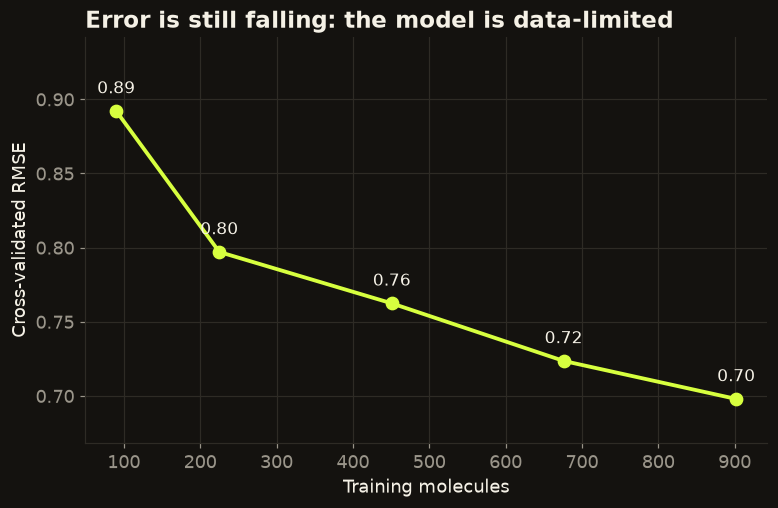

,training molecules,RMSE
0,90,0.89
1,225,0.80
2,451,0.76
3,676,0.72
4,902,0.70


In [12]:
X = df[DESCRIPTOR_COLS]
sizes, _, test_scores = learning_curve(chem.make_model(), X, df.logS, cv=KFold(5, shuffle=True, random_state=0),
                                       train_sizes=[0.1, 0.25, 0.5, 0.75, 1.0], scoring="neg_root_mean_squared_error", n_jobs=-1)
curve = pd.DataFrame({"training molecules": sizes, "RMSE": -test_scores.mean(axis=1)})
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(curve["training molecules"], curve.RMSE, color=ACCENT, lw=2.5, marker="o", ms=8)
for x, y in zip(curve["training molecules"], curve.RMSE):
    ax.text(x, y + 0.012, f"{y:.2f}", ha="center", fontsize=11)
ax.set_xlabel("Training molecules")
ax.set_ylabel("Cross-validated RMSE")
ax.set_ylim(curve.RMSE.min() - 0.03, curve.RMSE.max() + 0.05)
ax.set_title("Error is still falling: the model is data-limited")
save(fig, "06_learning_curve.png")
curve

## 7. Coverage: what the dataset does not contain

In [13]:
acids = df.mol.apply(lambda m: m.HasSubstructMatch(chem.Chem.MolFromSmarts("C(=O)[OX2H1]"))).sum()
print(f"Carboxylic acids in the dataset: {acids}")
print(f"Median molecular weight: {df.MW.median():.0f} g/mol (typical oral drugs are ~300-500)")
print(f"Molecules above 500 g/mol: {(df.MW > 500).sum()} of {len(df)}")

Carboxylic acids in the dataset: 0
Median molecular weight: 182 g/mol (typical oral drugs are ~300-500)
Molecules above 500 g/mol: 9 of 1128


## 8. Research opportunities

The errors are not noise: they cluster, and each cluster suggests a testable question.

| # | Observation (from this notebook) | Research question | How to test it |
|---|---|---|---|
| 1 | Organophosphates have ~2× the typical error and are **always under-predicted** (more soluble than expected). | Is the Crippen logP method mis-scoring phosphorus esters, or are these molecules genuinely behaving differently in water? | Compare Crippen logP with measured logP for the organophosphates; retrain with an alternative logP method or a phosphorus-specific correction and check whether the bias disappears. |
| 2 | Rigid, flat, crystalline molecules (e.g. anthraquinone) are **over-predicted**. | How much of the remaining error is solid-state (crystal packing) rather than molecular structure? | Add melting point, the key term in Yalkowsky's General Solubility Equation, from an open melting-point dataset, and measure how much the error drops for high-melting compounds. |
| 3 | Molecules with no close neighbour (similarity < 0.4) get ~50% larger errors. | Can the model reliably say *"I don't know"*? | Build an applicability-domain score (nearest-neighbour similarity or forest variance) and test whether it ranks the worst predictions first on held-out data. |
| 4 | The learning curve has not flattened. | How far can accuracy go with ~10× more data, and where is the measurement-noise floor? | Repeat the analysis on a larger curated set such as AqSolDB (~10k compounds) and use duplicate measurements to estimate the noise ceiling. |
| 5 | The dataset contains **no carboxylic acids** and few drug-sized molecules. | How badly do ESOL-style models fail on ionisable, drug-like compounds? | Evaluate on an external set of acids and larger molecules, ideally with pH-controlled solubility data. |

## 9. Summary

- **Oiliness (logP) is the dominant driver** of water solubility. Size, aromatic rings and halogens reduce it further.
- A random forest on 11 simple descriptors reaches **RMSE ≈ 0.70 log units** out-of-fold, beating the in-sample ESOL equation (≈ 0.91).
- Errors concentrate in **organophosphates**, **crystalline flat aromatics** and **unfamiliar chemistry**, which makes them research leads rather than random noise.

*Data: Delaney, J. S. "ESOL: Estimating Aqueous Solubility Directly from Molecular Structure", J. Chem. Inf. Comput. Sci. 2004, 44, 1000-1005. Distributed via MoleculeNet (Wu et al., 2018).*